Eduardo Alves Carvalho

2021017550

# Introdução

 Este documento traz uma breve discussão do entendimento do aluno frente a atividade
 proposta no laboratório 5. Para a realização de todos os itens da atividade foi desenvolvido um único algoritmo,
 que se encontra em anexo.
 Quanto aos valores escolhidos pelo aluno: a frequência utilizada para a gravação do
 áudio foi de 48 kHz, frequência normalmente utilizada em linhas telefônicas segundo o material
 da aula teórica; a taxa de amostragem utilizada no sinal gerado foi de 24 kHz, frequência
 normalmente utilizada para PCM segundo a aula teórica; o áudio gravado trata-se da frase
 “Olá testando”, pronunciada pelo aluno; o tempo de duração do áudio é de 5
 segundos; e o número de bits utilizado para a codificação foi o de 8 bits por amostra, valor
 normalmente utilizado segundo a aula teórica. Demais detalhes serão discutidos a seguir.

# Desenvolvimento

 Conforme foi pedido no item A, foi gerado um trecho do script onde é realizada a
 gravação de um áudio qualquer utilizando dos parâmetros informados anteriormente, ademais
 foi gerado um gráfico (figura 1) que torna possível observar o comportamento do sinal de áudio
 gerado. É importante ressaltar, que devido a fatores externos, como sensibilidade do microfone
 utilizado, há um ruído neste sinal, o que também nos é de interesse, afinal a observação do
 comportamento de sinais ruidosos é necessária por ser um caso recorrente em
 telecomunicações.

Importação das bibliotecas

In [22]:
import numpy as np
import sounddevice as sd
import soundfile as sf
import matplotlib.pyplot as plt

Leitura do áudio

In [23]:
arquivo_audio = "gravacao.wav"

try:
    original_audio, fs = sf.read(arquivo_audio)
    print(f"Arquivo '{arquivo_audio}' carregado com sucesso. Fs = {fs} Hz")
except FileNotFoundError:
    raise FileNotFoundError(f"O arquivo '{arquivo_audio}' não foi encontrado no diretório atual.")

# Vetor de tempo
t = np.arange(len(original_audio)) / fs

Arquivo 'gravacao.wav' carregado com sucesso. Fs = 48000 Hz


Gerando gráfico do sinal original

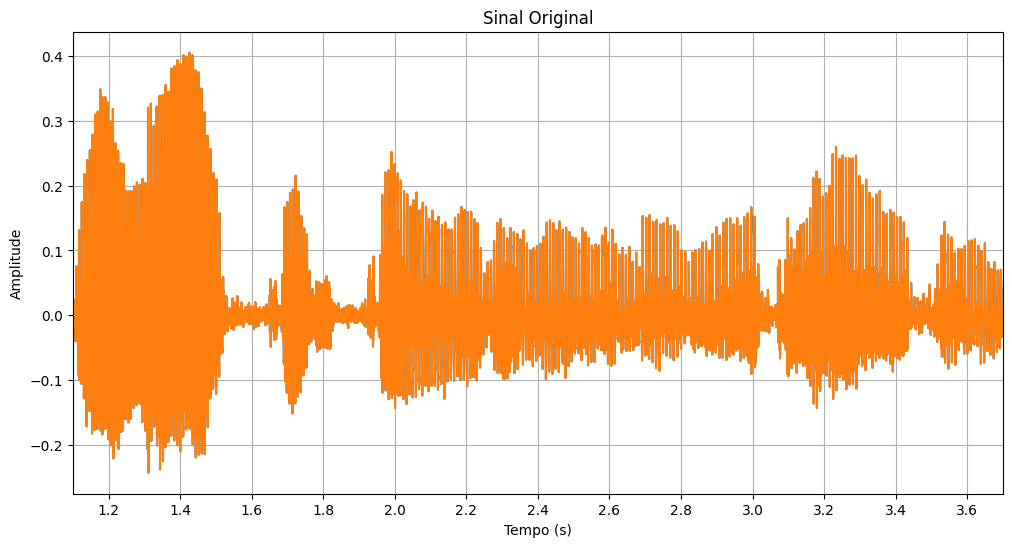

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(t, original_audio)
plt.xticks(np.arange(0, t[-1], 0.2))
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.xlim([1.1, 3.7])
#plt.xlim([1.2, 1.202])
plt.title("Sinal Original")
plt.grid(True)
plt.show()

 A fim de realizar a amostragem do sinal com a taxa de amostragem 8 kHz, foi gerado um
 novo vetor de tempo (t_amostrado), compatível com o tamanho do vetor para o sinal amostrado.
 Com isso, a quantidade de amostras aumentou de 17000 (dezessete mil) para 39998 (trinta e
 nove mil novecentas e noventa e oito) amostras. Como é possível ver na figura 2, não há grandes
 mudanças em relação ao sinal original. Devido a um espaçamento diferente, apenas alguns
 pontos são perdidos, o que é esperado quando um sinal é amostrado, porém mantendo-se o
 comportamento da onda original. Ao salvar o sinal amostrado em um arquivo de áudio é possível
 notar-se uma leve diferença entre a gravação original e o novo áudio gerado, que possui uma
 leve distorção na voz contida no arquivo, o que faz parecer que o áudio da amostragem pareça
 ter sido gravado com o microfone dentro de uma garrafa.

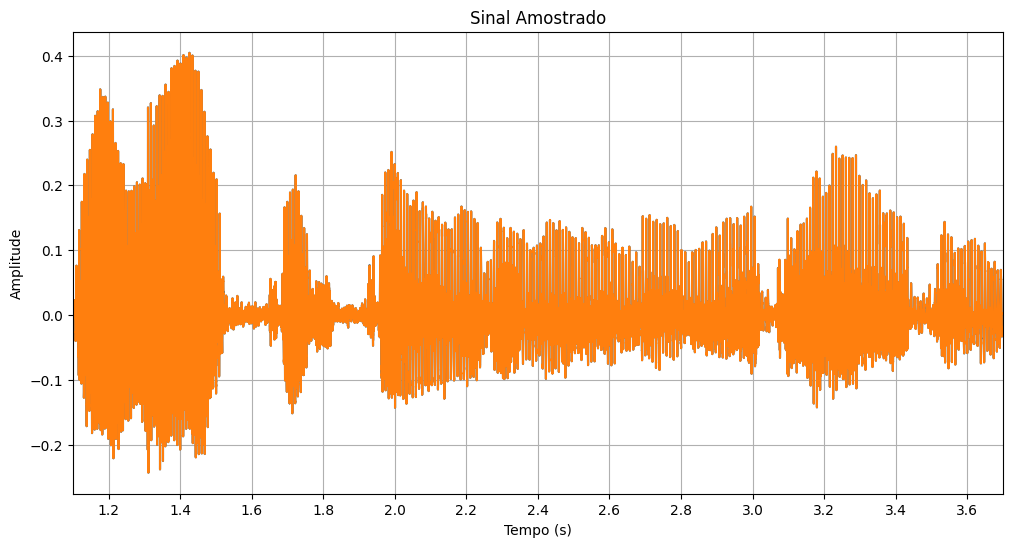

In [25]:
Fs_amostragem = 24000  # Nova taxa de amostragem

# Seleciona amostras proporcionalmente à taxa
passo = int(fs / Fs_amostragem)
sinal_amostrado = original_audio[::passo]
t_amostrado = np.arange(len(sinal_amostrado)) / Fs_amostragem
# Plot do sinal amostrado
plt.figure(figsize=(12, 6))
plt.plot(t_amostrado, sinal_amostrado)
plt.xticks(np.arange(0, t[-1], 0.2))
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.xlim([1.1, 3.7])
#plt.xlim([1.2, 1.202])  # trecho pequeno do sinal
plt.title("Sinal Amostrado")
plt.grid(True)
plt.show()

Diferente do caso anterior, na quantização é possível notar-se uma diferença no gráfico
 que expõe o comportamento do sinal quantizado (figura 3). Essa diferença vem da mudança de
 valores que ocorre na quantificação, tornando-os sempre valores múltiplos da metade do passo
 de quantificação, que nesse caso é de 1.449 * 10-3 do valor da amplitude. Tal valor é calculado
 pela equação 1, onde n trata-se do número de bits utilizados na codificação (2n também calcula o
 número de níveis de decisão, nesse caso 256) e Amaxcom Amin referem-se, respectivamente, ao
 maior e ao menor valor de amplitude da onda.
 Em decorrência dessa mudança na amplitude, ao gerar-se um áudio com o sinal
 quantizado, é possível de se notar uma diferença maior em relação ao áudio original e até
 mesmo em relação ao áudio gerado pelo sinal quantizado. A distorção gerada pela troca de
 valores das amplitudes ao longo do sinal é um pouco maior do que a gerada na amostragem.
 Além disso, o ruído de fundo se torna mais nítido, também devido a mudança de valores das
 amplitudes.

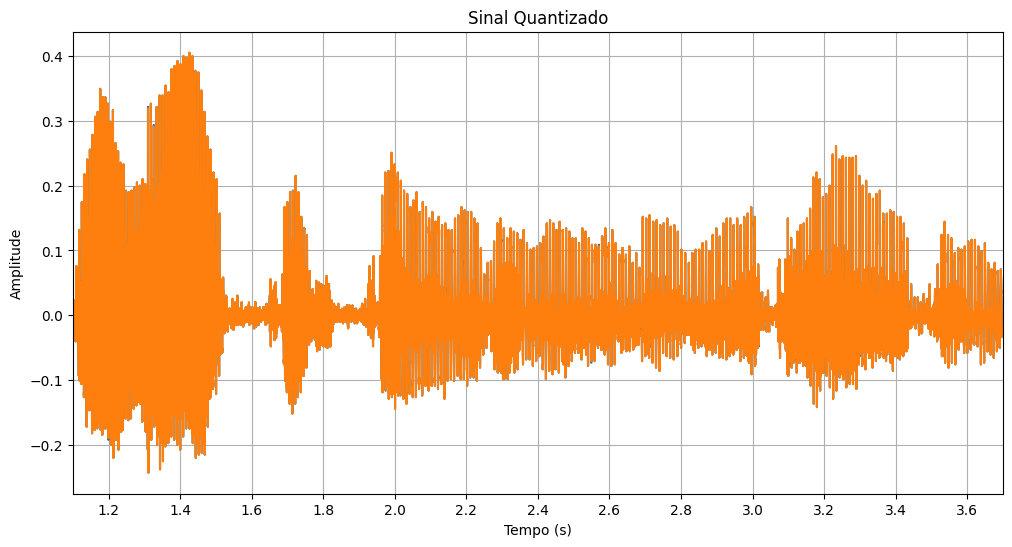

Intervalo de quantização: 0.002532


In [26]:
num_bits = 8
num_niveis_quantizacao = 2 ** num_bits

# Intervalo de quantização
quantization_range = (np.max(sinal_amostrado) - np.min(sinal_amostrado)) / num_niveis_quantizacao

sinal_quantizado = np.round(sinal_amostrado / quantization_range) * quantization_range

# Plot do sinal quantizado
plt.figure(figsize=(12, 6))
plt.plot(t_amostrado, sinal_quantizado)
plt.xticks(np.arange(0, t[-1], 0.2))
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("Sinal Quantizado")
plt.xlim([1.1, 3.7])
#plt.xlim([1.2, 1.202])  # trecho pequeno do sinal
plt.grid(True)
plt.show()

print(f"Intervalo de quantização: {quantization_range:.6f}")

 Por fim, o processo de codificação não traz grandes mudanças ao comportamento do
 sinal quantizado, como pode ser visto na figura 4, tendo apenas uma mudança na escala da
 amplitude, passando agora para números inteiros. Isso ocorre pois, o processo de codificação
 trabalha apenas realizando a troca dos valores quantizados por valores mais simples, atribuindo
 valores que representam apenas os níveis de quantização, tornando assim possível a codificação
 desses valores por meio do uso dos bits.

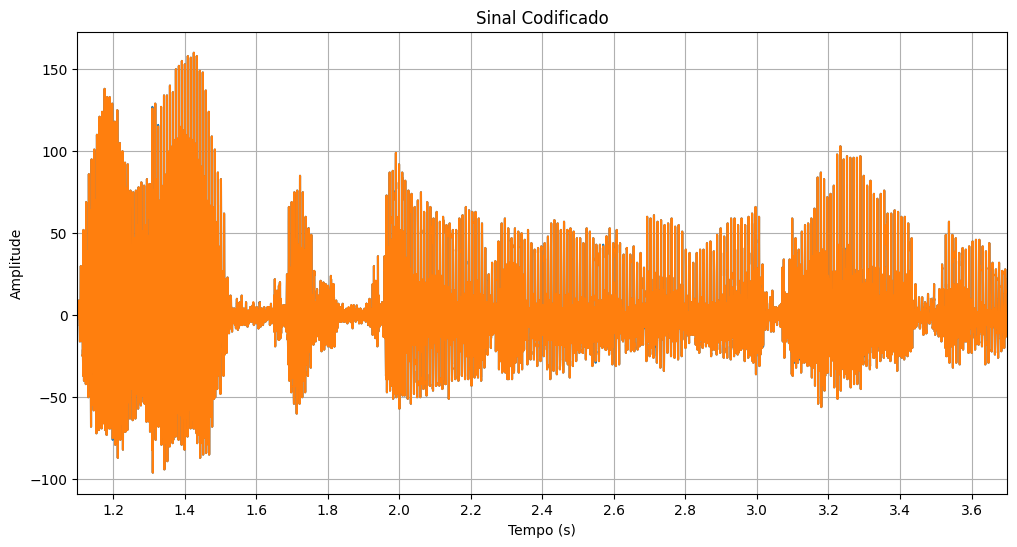

In [27]:
codificacao = np.round(sinal_quantizado / quantization_range)

# Plot do sinal codificado
plt.figure(figsize=(12, 6))
plt.plot(t_amostrado, codificacao)
plt.xticks(np.arange(0, t[-1], 0.2))
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("Sinal Codificado")
plt.xlim([1.1, 3.7])
plt.grid(True)
plt.show()

In [28]:
sf.write("amostrado.wav", sinal_amostrado, Fs_amostragem)
sf.write("quantizado.wav", sinal_quantizado, Fs_amostragem)
sf.write("codificado.wav", codificacao / 10, Fs_amostragem)

#print("Arquivos salvos: amostrado.wav, quantizado.wav e codificado.wav")


 Ademais, ao realizar a geração de um áudio com o sinal codificado, devido a sua
 mudança na escala da amplitude, o arquivo gerado continha um volume maior do que os
 anteriores, isso fez comque o ruído piorasse e, porventura, a qualidade do áudio fosse
 deteriorada. Embora ainda fosse possível de se ouvir e entender a mensagem expressa na
 gravação, mesmo após todo esse processo, para áudios muito ruidosos ou com amplitudes
 menores na informação de interesse, o procedimento pode ser prejudicial (a informação pode
 ser perdida) caso não sejam tomados os devidos cuidados com os valores dos parâmetros
 utilizados no mesmo.